In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.notebook import tqdm
from datasets import load_dataset

In [2]:
cc_raw = load_dataset("vblagoje/cc_news", split="train")
print(f"CC News: {len(cc_raw)} articles")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00005.parquet:   0%|          | 0.00/211M [00:00<?, ?B/s]

plain_text/train-00001-of-00005.parquet:   0%|          | 0.00/234M [00:00<?, ?B/s]

plain_text/train-00002-of-00005.parquet:   0%|          | 0.00/219M [00:00<?, ?B/s]

plain_text/train-00003-of-00005.parquet:   0%|          | 0.00/245M [00:00<?, ?B/s]

plain_text/train-00004-of-00005.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/708241 [00:00<?, ? examples/s]

CC News: 708241 articles


In [12]:
from datasets import load_dataset


start_year, end_year = 2017, 2019

bbc_dfs = []
for year in range(start_year, end_year + 1):
    for month in range(1, 13):
        config = f"{year}-{month:02d}"
        try:
            ds = load_dataset("RealTimeData/bbc_news_alltime", config, split="train")
            df = ds.to_pandas()
            df["year_month_config"] = config
            bbc_dfs.append(df)
            print(f"  {config}: {len(df)} articles")
        except Exception as e:
            print(f"  {config}: skipped ({e})")

bbc_df = pd.concat(bbc_dfs, ignore_index=True)
print(f"\nBBC News total: {len(bbc_df)} articles")
print("Columns:", bbc_df.columns.tolist())
bbc_df.head()

2017-01/train-00000-of-00001-e60bfec9cae(…):   0%|          | 0.00/2.86M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1688 [00:00<?, ? examples/s]

  2017-01: 1688 articles


2017-02/train-00000-of-00001-8de593cb8ac(…):   0%|          | 0.00/2.53M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1469 [00:00<?, ? examples/s]

...

  2019-11: 1275 articles


2019-12/train-00000-of-00001-0614f9b197f(…):   0%|          | 0.00/2.24M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1304 [00:00<?, ? examples/s]

  2019-12: 1304 articles

BBC News total: 44777 articles
Columns: ['title', 'published_date', 'authors', 'description', 'section', 'content', 'link', 'top_image', 'year_month_config']


,title,published_date,authors,description,section,content,link,top_image,year_month_config
0,Saido Berahino: Stoke complete deal to sign We...,2017-01-21,None,Stoke sign West Brom striker Saido Berahino fo...,None,Last updated on .From the section Football\n\n...,http://www.bbc.co.uk/sport/football/38696547,https://ichef.bbci.co.uk/onesport/cps/624/cpsp...,2017-01
1,Lawro's Premier League predictions v Split sta...,2017-01-21,None,BBC football expert Mark Lawrenson takes on ac...,None,Last updated on .From the section Football\n\n...,http://www.bbc.co.uk/sport/football/38632703,https://ichef.bbci.co.uk/onesport/cps/624/cpsp...,2017-01
2,Chapecoense plane: Footballer Neto dreamt of c...,2017-01-21,None,Chapecoense football club player Neto is one o...,None,Chapecoense footballer Neto is one of six surv...,http://www.bbc.co.uk/news/world-latin-america-...,https://ichef.bbci.co.uk/news/1024/branded_new...,2017-01
3,Australian Open: Johanna Konta praises support...,2017-01-21,None,Great Britain's Johanna Konta says her family ...,None,Last updated on .From the section Tennis\n\nCo...,http://www.bbc.co.uk/sport/tennis/38704836,https://ichef.bbci.co.uk/onesport/cps/624/cpsp...,2017-01
4,Friends' 30-year-search for Celtic treasure tr...,2017-01-21,None,Two metal detector enthusiasts found a huge ho...,None,A 30-year obsession finally paid off for two m...,http://www.bbc.co.uk/news/world-europe-38703914,https://ichef.bbci.co.uk/news/1024/branded_new...,2017-01


In [16]:
print("Columns:", bbc_df.columns.tolist())
print("\nSample article:")
for k, v in bbc_df.iloc[0].items():
    print(f"  {k}: {str(v)[:200]}")

Columns: ['title', 'published_date', 'authors', 'description', 'section', 'content', 'link', 'top_image', 'year_month_config']

Sample article:
  title: Saido Berahino: Stoke complete deal to sign West Brom's 23-year-old striker - BBC Sport
  published_date: 2017-01-21
  authors: None
  description: Stoke sign West Brom striker Saido Berahino for £12m on a five-and-a-half-year deal.
  section: None
  content: Last updated on .From the section Football

Stoke have signed West Brom striker Saido Berahino for a fee of £12m on a five-and-a-half-year deal.

The 23-year-old's contract had been due to expire at t
  link: http://www.bbc.co.uk/sport/football/38696547
  top_image: https://ichef.bbci.co.uk/onesport/cps/624/cpsprodpb/129BB/production/_93691267_berahino_getty.jpg
  year_month_config: 2017-01


In [17]:
# Standardize columns — adjust field names based on what the cell above shows
# Common BBC fields: title, description, content, published_date, section, url

# Find the right text column
text_col = None
for candidate in ["content", "text", "description", "body"]:
    if candidate in bbc_df.columns:
        text_col = candidate
        break
print(f"Using '{text_col}' as text column")

# Find the right date column
date_col = None
for candidate in ["published_date", "date", "pubDate", "published"]:
    if candidate in bbc_df.columns:
        date_col = candidate
        break
print(f"Using '{date_col}' as date column")

# Find category column
cat_col = None
for candidate in ["category", "section", "topic"]:
    if candidate in bbc_df.columns:
        cat_col = candidate
        break
print(f"Using '{cat_col}' as category column")

Using 'content' as text column
Using 'published_date' as date column
Using 'section' as category column


In [18]:
# Build standardized DataFrame
bbc_df["id"] = [f"bbc_{i}" for i in range(len(bbc_df))]
bbc_df["source"] = "bbc_news"
bbc_df["domain"] = "bbc.com"

# Rename text column
if text_col and text_col != "text":
    bbc_df.rename(columns={text_col: "text"}, inplace=True)

# Parse dates
if date_col:
    bbc_df["date"] = pd.to_datetime(bbc_df[date_col], errors="coerce")
else:
    # Fall back to the config label we added during loading
    bbc_df["date"] = pd.to_datetime(bbc_df["year_month_config"] + "-01", errors="coerce")

# Category
if cat_col:
    bbc_df["category"] = bbc_df[cat_col]
else:
    bbc_df["category"] = None

# Word count
bbc_df["word_count"] = bbc_df["text"].fillna("").apply(lambda x: len(x.split()))

print(f"BBC News DataFrame: {len(bbc_df)} rows")
print(f"Valid dates: {bbc_df['date'].notna().sum()}")
print(f"Date range: {bbc_df['date'].min()} → {bbc_df['date'].max()}")
bbc_df.head()


BBC News DataFrame: 44777 rows
Valid dates: 44777
Date range: 2017-01-01 00:00:00 → 2019-12-27 00:00:00


,title,published_date,authors,description,section,text,link,top_image,year_month_config,id,source,domain,date,category,word_count
0,Saido Berahino: Stoke complete deal to sign We...,2017-01-21,None,Stoke sign West Brom striker Saido Berahino fo...,None,Last updated on .From the section Football\n\n...,http://www.bbc.co.uk/sport/football/38696547,https://ichef.bbci.co.uk/onesport/cps/624/cpsp...,2017-01,bbc_0,bbc_news,bbc.com,2017-01-21,None,329
1,Lawro's Premier League predictions v Split sta...,2017-01-21,None,BBC football expert Mark Lawrenson takes on ac...,None,Last updated on .From the section Football\n\n...,http://www.bbc.co.uk/sport/football/38632703,https://ichef.bbci.co.uk/onesport/cps/624/cpsp...,2017-01,bbc_1,bbc_news,bbc.com,2017-01-21,None,363
2,Chapecoense plane: Footballer Neto dreamt of c...,2017-01-21,None,Chapecoense football club player Neto is one o...,None,Chapecoense footballer Neto is one of six surv...,http://www.bbc.co.uk/news/world-latin-america-...,https://ichef.bbci.co.uk/news/1024/branded_new...,2017-01,bbc_2,bbc_news,bbc.com,2017-01-21,None,41
3,Australian Open: Johanna Konta praises support...,2017-01-21,None,Great Britain's Johanna Konta says her family ...,None,Last updated on .From the section Tennis\n\nCo...,http://www.bbc.co.uk/sport/tennis/38704836,https://ichef.bbci.co.uk/onesport/cps/624/cpsp...,2017-01,bbc_3,bbc_news,bbc.com,2017-01-21,None,371
4,Friends' 30-year-search for Celtic treasure tr...,2017-01-21,None,Two metal detector enthusiasts found a huge ho...,None,A 30-year obsession finally paid off for two m...,http://www.bbc.co.uk/news/world-europe-38703914,https://ichef.bbci.co.uk/news/1024/branded_new...,2017-01,bbc_4,bbc_news,bbc.com,2017-01-21,None,44


In [3]:
print("Columns:", cc_raw.column_names)
print("\nSample article:")
for k, v in cc_raw[0].items():
    print(f"  {k}: {str(v)[:200]}")

Columns: ['title', 'text', 'domain', 'date', 'description', 'url', 'image_url']

Sample article:
  title: Daughter Duo is Dancing in The Same Company
  text: There's a surprising twist to Regina Willoughby's last season with Columbia City Ballet: It's also her 18-year-old daughter Melina's first season with the company. Regina, 40, will retire from the sta
  domain: www.pointemagazine.com
  date: 2017-12-11 20:19:05
  description: There's a surprising twist to Regina Willoughby's last season with Columbia City Ballet: It's also her 18-year-old daughter Melina's first season with the company.
  url: http://www.pointemagazine.com/mother-daughter-duo-dancing-2516681965.html
  image_url: https://pointe-img.rbl.ms/simage/https%3A%2F%2Fassets.rbl.ms%2F16807693%2F980x.png/2000%2C2000/3VnhNGWp75K4SwMx/img.png


In [4]:
cc_df = cc_raw.to_pandas()

# Rename/add columns to match our schema
cc_df["id"] = [f"cc_{i}" for i in range(len(cc_df))]
cc_df["date"] = pd.to_datetime(cc_df["date"], errors="coerce")
cc_df["word_count"] = cc_df["text"].fillna("").apply(lambda x: len(x.split()))
cc_df["source"] = "cc_news"
cc_df["category"] = None

print(f"CC News DataFrame: {len(cc_df)} rows")
cc_df.head()

CC News DataFrame: 708241 rows


,title,text,domain,date,description,url,image_url,id,word_count,source,category
0,Daughter Duo is Dancing in The Same Company,There's a surprising twist to Regina Willoughb...,www.pointemagazine.com,2017-12-11 20:19:05,There's a surprising twist to Regina Willoughb...,http://www.pointemagazine.com/mother-daughter-...,https://pointe-img.rbl.ms/simage/https%3A%2F%2...,cc_0,147,cc_news,None
1,New York City Ballet Announces Interim Leaders...,The New York City Ballet Board of Directors an...,www.pointemagazine.com,2017-12-11 17:02:55,NYCB has announced an interim leadership team ...,http://www.pointemagazine.com/nycb-interim-lea...,https://pointe-img.rbl.ms/simage/https%3A%2F%2...,cc_1,193,cc_news,None
2,Watch Pennsylvania Ballet & Boston Ballet Face...,The Philadelphia Eagles and the New England Pa...,www.pointemagazine.com,2018-02-02 21:58:13,The Philadelphia Eagles and the New England Pa...,http://www.pointemagazine.com/watch-pennsylvan...,https://pointe-img.rbl.ms/simage/https%3A%2F%2...,cc_2,149,cc_news,None
3,dance shoes,Looking for your next audition shoe? Shot at a...,www.pointemagazine.com,2018-04-24 19:00:11,Looking for your next audition shoe? Shot at a...,https://www.pointemagazine.com/dance-shoes-256...,https://pointe-img.rbl.ms/simage/https%3A%2F%2...,cc_3,74,cc_news,None
4,Rebecca Krohn on Her Retirement from New York ...,New York City Ballet principal dancer Rebecca ...,www.pointemagazine.com,2017-10-06 14:44:51,We interviewed New York City Ballet principal ...,http://www.pointemagazine.com/rebecca-krohn-re...,https://pointe-img.rbl.ms/simage/https%3A%2F%2...,cc_4,877,cc_news,None


In [7]:
cc_df.drop('image_url', axis=1, inplace=True)

In [5]:
print(f"Total articles: {len(cc_df)}")
valid = cc_df["date"].dropna()
print(f"Valid dates: {len(valid)} ({100*len(valid)/len(cc_df):.1f}%)")
if len(valid) > 0:
    print(f"Date range: {valid.min()} → {valid.max()}")
print(f"\nWord count — mean: {cc_df['word_count'].mean():.0f}, median: {cc_df['word_count'].median():.0f}")
print(f"Stubs (<50 words): {(cc_df['word_count'] < 50).sum()}")
print(f"Short (<100 words): {(cc_df['word_count'] < 100).sum()}")
print(f"Null titles: {cc_df['title'].isna().sum()}")
print(f"Empty text: {(cc_df['text'] == '').sum() + cc_df['text'].isna().sum()}")
print(f"\nTop 15 domains:")
print(cc_df["domain"].value_counts().head(15))

Total articles: 708241
Valid dates: 630643 (89.0%)
Date range: 2017-01-01 00:00:00 → 2019-08-25 20:17:00

Word count — mean: 397, median: 291
Stubs (<50 words): 68205
Short (<100 words): 141430
Null titles: 0
Empty text: 0

Top 15 domains:
domain
uk.reuters.com             24480
www.dailymail.co.uk        15452
www.topix.com              13354
www.reuters.com            11378
www.which.co.uk             7411
www.express.co.uk           4875
indianexpress.com           4151
www.cbssports.com           4039
www.mirror.co.uk            3791
nypost.com                  3646
shepherdexpress.com         3605
www.channelnewsasia.com     3462
www.cnn.com                 3403
www.amarujala.com           3395
nationalpost.com            3238
Name: count, dtype: int64


In [19]:
# Basic stats
print(f"Total articles: {len(bbc_df)}")
print(f"\nWord count — mean: {bbc_df['word_count'].mean():.0f}, median: {bbc_df['word_count'].median():.0f}")
print(f"Stubs (<50 words): {(bbc_df['word_count'] < 50).sum()}")
print(f"Short (<100 words): {(bbc_df['word_count'] < 100).sum()}")
print(f"Null titles: {bbc_df['title'].isna().sum()}")
print(f"Empty text: {(bbc_df['text'] == '').sum() + bbc_df['text'].isna().sum()}")

if bbc_df["category"].notna().any():
    print(f"\nCategory distribution:")
    print(bbc_df["category"].value_counts().head(15))

Total articles: 44777

Word count — mean: 559, median: 486
Stubs (<50 words): 3120
Short (<100 words): 5571
Null titles: 0
Empty text: 0

Category distribution:
category
UK                       4179
Business                 3535
UK Politics              3409
Entertainment & Arts     2240
US & Canada              2230
Europe                   1661
London                   1471
Health                   1019
Technology                930
Asia                      750
Wales                     720
Northern Ireland          690
England                   589
Science & Environment     569
Middle East               511
Name: count, dtype: int64


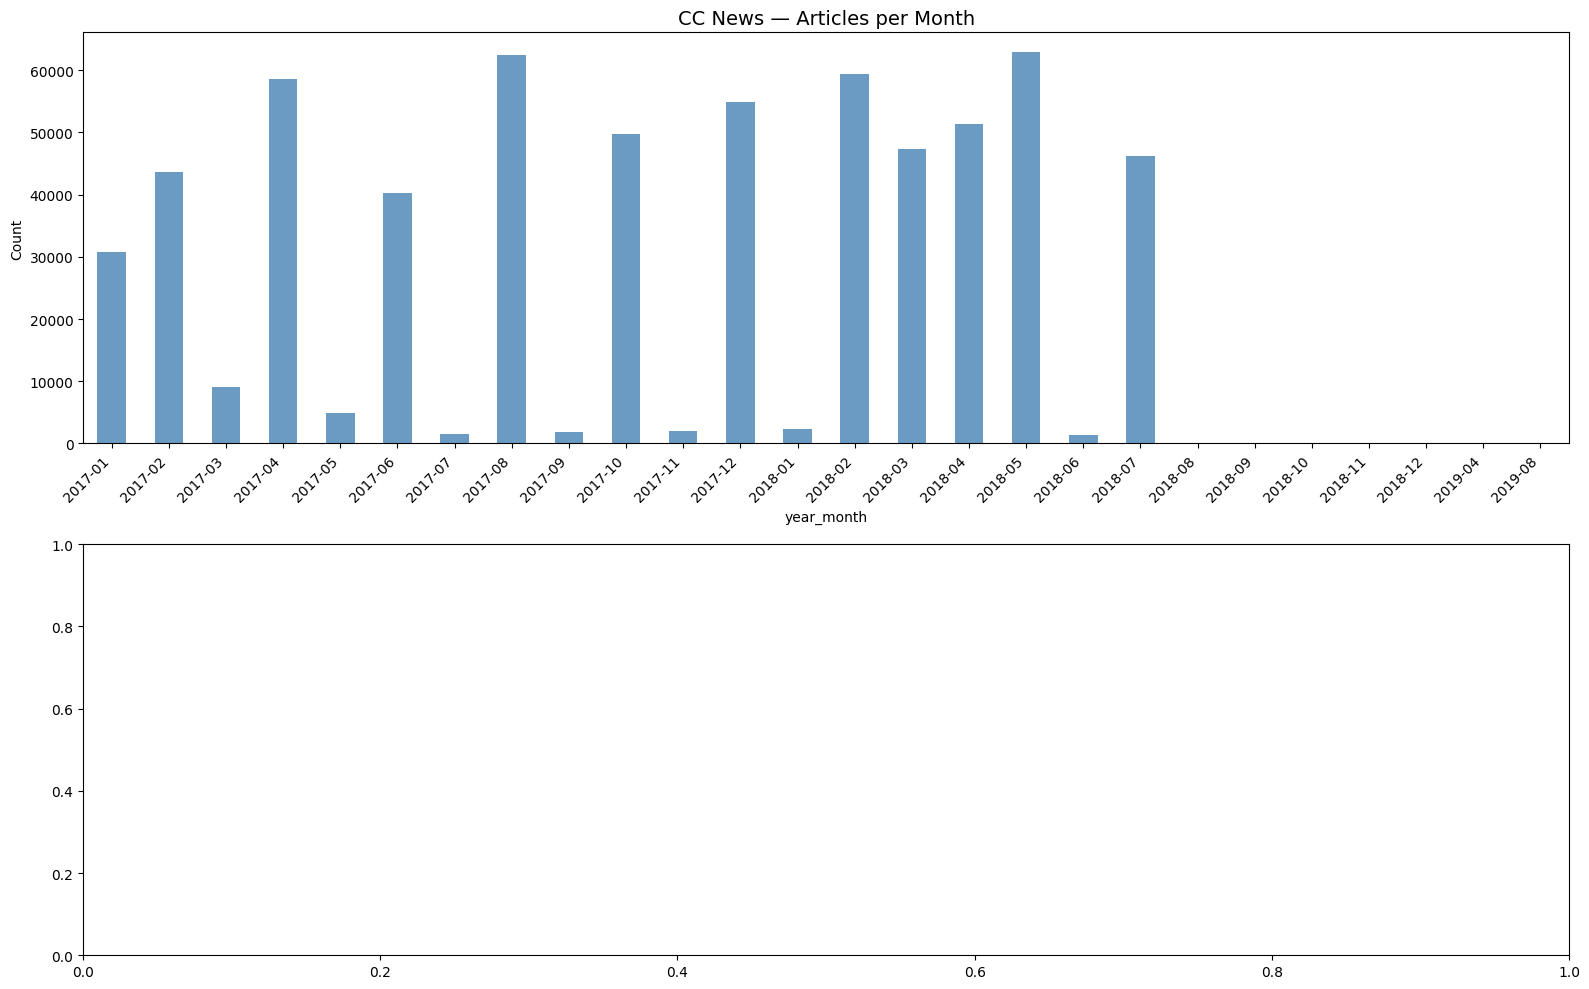

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, (name, df) in zip(axes, [("CC News", cc_df)]):
    valid = df[df["date"].notna()].copy()
    valid["year_month"] = valid["date"].dt.to_period("M")
    counts = valid["year_month"].value_counts().sort_index()

    counts.plot(kind="bar", ax=ax, color="steelblue", alpha=0.8)
    ax.set_title(f"{name} — Articles per Month", fontsize=14)
    ax.set_ylabel("Count")

    n = len(counts)
    step = max(1, n // 20)
    ax.set_xticks(range(0, n, step))
    ax.set_xticklabels([str(counts.index[i]) for i in range(0, n, step)], rotation=45, ha="right")

plt.tight_layout()
plt.show()

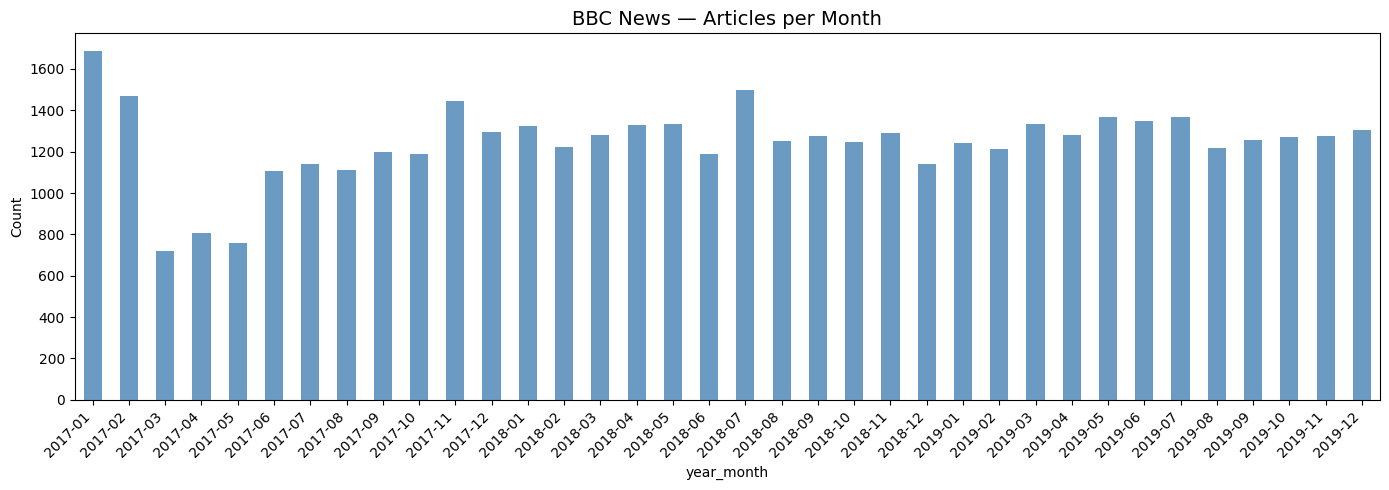

In [20]:
# Monthly distribution plot
valid = bbc_df[bbc_df["date"].notna()].copy()
valid["year_month"] = valid["date"].dt.to_period("M")
counts = valid["year_month"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
counts.plot(kind="bar", ax=ax, color="steelblue", alpha=0.8)
ax.set_title("BBC News — Articles per Month", fontsize=14)
ax.set_ylabel("Count")
n = len(counts)
step = max(1, n // 20)
ax.set_xticks(range(0, n, step))
ax.set_xticklabels([str(counts.index[i]) for i in range(0, n, step)], rotation=45, ha="right")
plt.tight_layout()
plt.show()

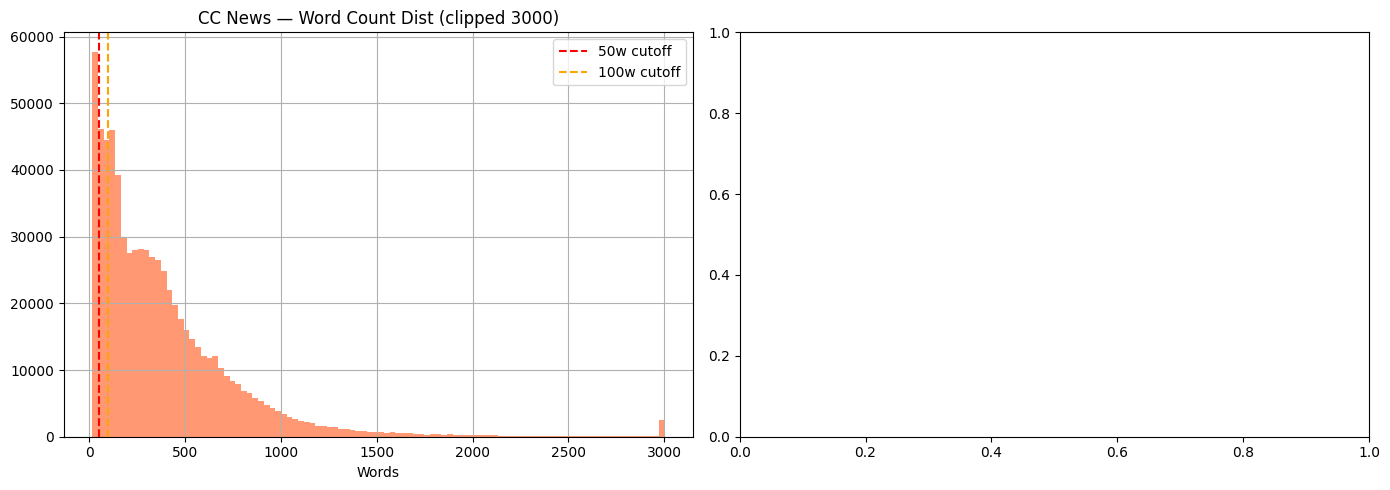

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [("CC News", cc_df)]):
    df["word_count"].clip(upper=3000).hist(bins=100, ax=ax, color="coral", alpha=0.8)
    ax.set_title(f"{name} — Word Count Dist (clipped 3000)")
    ax.set_xlabel("Words")
    ax.axvline(50, color="red", ls="--", label="50w cutoff")
    ax.axvline(100, color="orange", ls="--", label="100w cutoff")
    ax.legend()

plt.tight_layout()
plt.show()

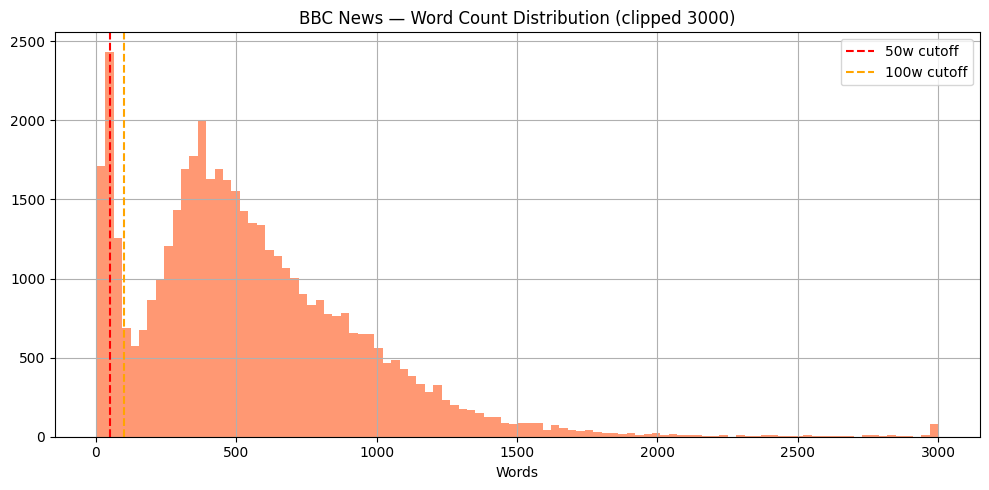

In [21]:
# Word count distribution
fig, ax = plt.subplots(figsize=(10, 5))
bbc_df["word_count"].clip(upper=3000).hist(bins=100, ax=ax, color="coral", alpha=0.8)
ax.set_title("BBC News — Word Count Distribution (clipped 3000)")
ax.set_xlabel("Words")
ax.axvline(50, color="red", ls="--", label="50w cutoff")
ax.axvline(100, color="orange", ls="--", label="100w cutoff")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
for name, df in [("CC News", cc_df)]:
    title_dupes = df[df["title"].notna()]["title"].duplicated().sum()
    df["_hash"] = df["text"].apply(lambda x: hash(str(x)[:500]) if x else None)
    text_dupes = df[df["_hash"].notna()]["_hash"].duplicated().sum()
    print(f"{name}: {title_dupes} duplicate titles, {text_dupes} duplicate text hashes")

CC News: 156534 duplicate titles, 154568 duplicate text hashes


In [22]:
# Duplicate check
title_dupes = bbc_df[bbc_df["title"].notna()]["title"].duplicated().sum()
bbc_df["_hash"] = bbc_df["text"].fillna("").apply(lambda x: hash(x[:500]))
text_dupes = bbc_df["_hash"].duplicated().sum()
print(f"Duplicate titles: {title_dupes}")
print(f"Duplicate text hashes: {text_dupes}")

Duplicate titles: 12487
Duplicate text hashes: 12538


In [23]:
cc_valid = cc_df[cc_df["date"].notna()]
bbc_valid = bbc_df[bbc_df["date"].notna()]

overlap_start = max(cc_valid["date"].min(), bbc_valid["date"].min())
overlap_end = min(cc_valid["date"].max(), bbc_valid["date"].max())

if overlap_start < overlap_end:
    print(f"Overlapping range: {overlap_start} → {overlap_end}")
    print(f"CC articles in overlap: {((cc_valid['date'] >= overlap_start) & (cc_valid['date'] <= overlap_end)).sum()}")
    print(f"BBC articles in overlap: {((bbc_valid['date'] >= overlap_start) & (bbc_valid['date'] <= overlap_end)).sum()}")
else:
    print("No date overlap between datasets")

Overlapping range: 2017-01-01 00:00:00 → 2019-08-25 20:17:00
CC articles in overlap: 630643
BBC articles in overlap: 39585


In [24]:
print("CC News:")
print(f"  Articles (>=100 words): {(cc_df['word_count'] >= 100).sum()}")
print(f"  Date range: {cc_df['date'].min()} → {cc_df['date'].max()}")

print("\nBBC News:")
print(f"  Articles (>=100 words): {(bbc_df['word_count'] >= 100).sum()}")
print(f"  Date range: {bbc_df['date'].min()} → {bbc_df['date'].max()}")

CC News:
  Articles (>=100 words): 566811
  Date range: 2017-01-01 00:00:00 → 2019-08-25 20:17:00

BBC News:
  Articles (>=100 words): 39206
  Date range: 2017-01-01 00:00:00 → 2019-12-27 00:00:00


In [25]:
explore_df = bbc_df[bbc_df["date"].notna() & (bbc_df["word_count"] >= 100)].copy()
explore_df["year_month"] = explore_df["date"].dt.to_period("M")

month_counts = explore_df["year_month"].value_counts().sort_index()
print("Monthly counts:")
print(month_counts.to_string())

Monthly counts:
year_month
2017-01    1183
2017-02    1050
2017-03     687
2017-04     756
2017-05     719
2017-06    1075
2017-07    1133
2017-08    1094
2017-09    1181
2017-10    1168
2017-11    1241
2017-12    1082
2018-01    1133
2018-02    1037
2018-03    1069
2018-04    1114
2018-05    1072
2018-06    1001
2018-07    1266
2018-08    1079
2018-09    1085
2018-10    1052
2018-11    1108
2018-12     994
2019-01    1082
2019-02    1090
2019-03    1186
2019-04    1152
2019-05    1203
2019-06    1212
2019-07    1232
2019-08    1108
2019-09    1113
2019-10    1143
2019-11    1137
2019-12    1169
Freq: M


In [26]:
# Select 3 consecutive months with good coverage
good_months = month_counts[month_counts >= 30].sort_index()
if len(good_months) >= 3:
    selected_months = good_months.index[-3:]
else:
    selected_months = month_counts.nlargest(3).index

print(f"Selected months: {list(selected_months)}")

subset = explore_df[explore_df["year_month"].isin(selected_months)].copy()
capped = []
for m in selected_months:
    chunk = subset[subset["year_month"] == m]
    capped.append(chunk.sample(min(500, len(chunk)), random_state=42))
subset = pd.concat(capped).reset_index(drop=True)

for m in selected_months:
    print(f"  {m}: {(subset['year_month'] == m).sum()} articles")
print(f"Total: {len(subset)}")

Selected months: [Period('2019-10', 'M'), Period('2019-11', 'M'), Period('2019-12', 'M')]
  2019-10: 500 articles
  2019-11: 500 articles
  2019-12: 500 articles
Total: 1500


In [27]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = [
    f"{row['title'] or ''}. {' '.join((row['text'] or '').split()[:256])}"
    for _, row in subset.iterrows()
]

embeddings = model.encode(texts, show_progress_bar=True, batch_size=64)
embeddings = np.array(embeddings)

norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1
embeddings_norm = embeddings / norms

print(f"Embeddings shape: {embeddings_norm.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Embeddings shape: (1500, 384)


In [28]:
SIMILARITY_THRESHOLD = 0.75

sorted_months = sorted(selected_months)
pairs = []

for i, older in enumerate(sorted_months[:-1]):
    for newer in sorted_months[i+1:]:
        old_idx = subset[subset["year_month"] == older].index.values
        new_idx = subset[subset["year_month"] == newer].index.values

        sim = embeddings_norm[old_idx] @ embeddings_norm[new_idx].T
        above = np.where(sim >= SIMILARITY_THRESHOLD)

        for oi, ni in zip(above[0], above[1]):
            og = old_idx[oi]
            ng = new_idx[ni]
            pairs.append({
                "old_id": subset.loc[og, "id"],
                "old_title": subset.loc[og, "title"],
                "old_month": str(older),
                "new_id": subset.loc[ng, "id"],
                "new_title": subset.loc[ng, "title"],
                "new_month": str(newer),
                "similarity": float(sim[oi, ni]),
            })

pairs_df = pd.DataFrame(pairs).sort_values("similarity", ascending=False).reset_index(drop=True)
print(f"Pairs above {SIMILARITY_THRESHOLD}: {len(pairs_df)}")

Pairs above 0.75: 208


In [29]:
for _, row in pairs_df.head(20).iterrows():
    print(f"\n  sim={row['similarity']:.4f}")
    print(f"  OLD [{row['old_month']}]: {row['old_title']}")
    print(f"  NEW [{row['new_month']}]: {row['new_title']}")


  sim=1.0000
  OLD [2019-11]: The story of Tunnel 29
  NEW [2019-12]: The story of Tunnel 29

  sim=1.0000
  OLD [2019-11]: Prince Andrew's links to Jeffrey Epstein - BBC News
  NEW [2019-12]: Prince Andrew's links to Jeffrey Epstein - BBC News

  sim=1.0000
  OLD [2019-11]: Prince Andrew's links to Jeffrey Epstein - BBC News
  NEW [2019-12]: Prince Andrew's links to Jeffrey Epstein - BBC News

  sim=1.0000
  OLD [2019-10]: Brexit: What happens now? - BBC News
  NEW [2019-12]: Brexit: What happens now? - BBC News

  sim=1.0000
  OLD [2019-11]: Who should I vote for? General election 2019: Compare the party manifestos - BBC News
  NEW [2019-12]: Who should I vote for? General election 2019: Compare the party manifestos - BBC News

  sim=1.0000
  OLD [2019-11]: Who should I vote for? General election 2019: Compare the party manifestos - BBC News
  NEW [2019-12]: Who should I vote for? General election 2019: Compare the party manifestos - BBC News

  sim=1.0000
  OLD [2019-11]: Who shoul

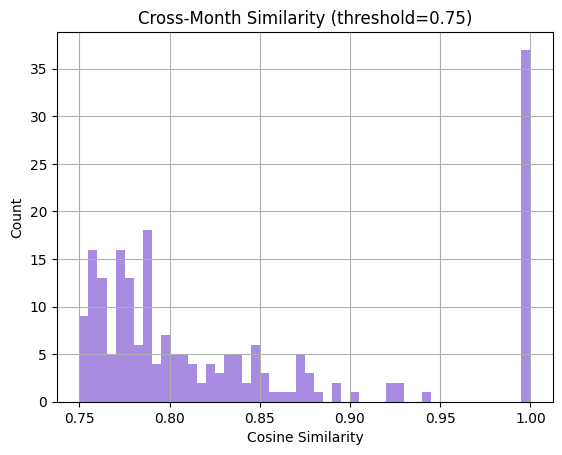

Saved cross_month_similar_pairs.csv


In [30]:
if len(pairs_df) > 0:
    pairs_df["similarity"].hist(bins=50, color="mediumpurple", alpha=0.8)
    plt.title(f"Cross-Month Similarity (threshold={SIMILARITY_THRESHOLD})")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Count")
    plt.show()

    pairs_df.to_csv("cross_month_similar_pairs.csv", index=False)
    print("Saved cross_month_similar_pairs.csv")
else:
    print("No pairs found — try lowering SIMILARITY_THRESHOLD to 0.6 or 0.65")

In [31]:
# Filter out exact duplicates (same title = BBC re-publishing)
real_pairs = pairs_df[pairs_df["old_title"] != pairs_df["new_title"]].copy()
real_pairs = real_pairs.sort_values("similarity", ascending=False).reset_index(drop=True)

print(f"Supersession candidates (different titles): {len(real_pairs)}")
print("\nTop 20:")
for _, row in real_pairs.head(20).iterrows():
    print(f"\n  sim={row['similarity']:.4f}")
    print(f"  OLD [{row['old_month']}]: {row['old_title']}")
    print(f"  NEW [{row['new_month']}]: {row['new_title']}")

Supersession candidates (different titles): 171

Top 20:

  sim=0.9443
  OLD [2019-10]: Meghan sues Mail on Sunday over private letter - BBC News
  NEW [2019-11]: Meghan accuses Mail newspapers of 'untrue' stories - court papers - BBC News

  sim=0.9285
  OLD [2019-11]: Candidate guilty of harassing seat opponent Anna Soubry - BBC News
  NEW [2019-12]: Election candidate guilty of harassing MP Anna Soubry - BBC News

  sim=0.9285
  OLD [2019-11]: Candidate guilty of harassing seat opponent Anna Soubry - BBC News
  NEW [2019-12]: Election candidate guilty of harassing MP Anna Soubry - BBC News

  sim=0.9238
  OLD [2019-10]: Cambridge University don readmitted after sexual harassment - BBC News
  NEW [2019-11]: Cambridge University academic resigns after Trinity Hall row - BBC News

  sim=0.9238
  OLD [2019-10]: Cambridge University don readmitted after sexual harassment - BBC News
  NEW [2019-11]: Cambridge University academic resigns after Trinity Hall row - BBC News

  sim=0.9017
  OL